In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/08450.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/19812.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/16916.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/05938.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/06122.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/08536.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/12666.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/04168.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/13288.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/02371.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/04377.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/09924.jpg
/kaggle/input/datasets/arunrk7/surface-crack-detection/Negative/00767.jpg
/kaggle/input/datasets/arunrk7/surface

In [1]:
# Install and import libraries, mount Google Drive
!pip install -q opencv-python-headless matplotlib seaborn scikit-learn tensorflow

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import kagglehub
import shutil
import cv2
import random
from google.colab import drive, files
import warnings
warnings.filterwarnings('ignore')


In [8]:
PROJECT_ROOT = '/kaggle/working/'

In [9]:

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'models'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'artifacts', 'plots'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'artifacts', 'metrics'), exist_ok=True)

In [10]:
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


In [11]:
# Cell 2 for Kaggle – dataset already mounted
dataset_path = '/kaggle/input/datasets/arunrk7/surface-crack-detection'
source_dir = dataset_path  # the folder contains Positive/ and Negative/
print("Dataset location:", source_dir)

# Copy images to a temporary structured folder (or use them directly)
temp_data = '/kaggle/working/concrete_data'
import shutil
if os.path.exists(temp_data):
    shutil.rmtree(temp_data)
for cls in ['Positive', 'Negative']:
    shutil.copytree(os.path.join(source_dir, cls), os.path.join(temp_data, cls))

print("Image counts:")
for cls in ['Positive', 'Negative']:
    print(f"{cls}: {len(os.listdir(os.path.join(temp_data, cls)))}")

Dataset location: /kaggle/input/datasets/arunrk7/surface-crack-detection
Image counts:
Positive: 20000
Negative: 20000


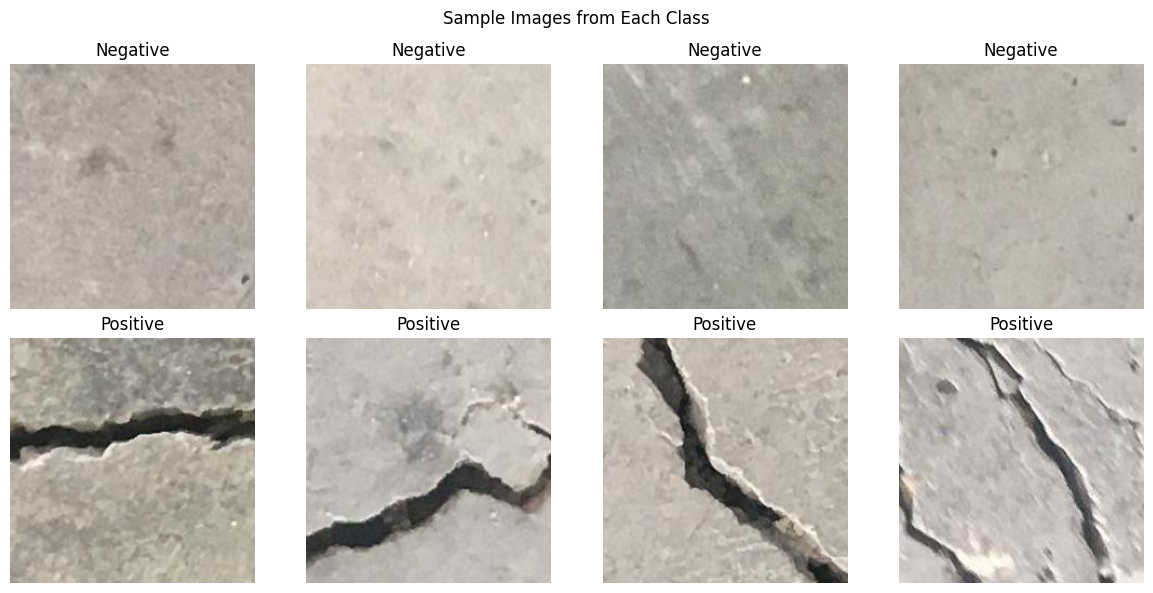

In [12]:
# Cell 3: Show a few sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, cls in enumerate(['Negative', 'Positive']):
    class_dir = os.path.join(temp_data, cls)
    samples = random.sample(os.listdir(class_dir), 4)
    for j, fname in enumerate(samples):
        img = plt.imread(os.path.join(class_dir, fname))
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(cls)
        axes[i, j].axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'artifacts', 'plots', 'sample_images.png'), dpi=150)
plt.show()

In [13]:
# Cell 4: Stratified split (per class) to preserve class balance
from sklearn.model_selection import train_test_split

split_root = '/content/split_data'
if os.path.exists(split_root):
    shutil.rmtree(split_root)

def split_class(cls, split=(0.7, 0.15, 0.15)):
    src = os.path.join(temp_data, cls)
    files = os.listdir(src)
    np.random.seed(42)
    np.random.shuffle(files)
    n = len(files)
    train_end = int(split[0]*n)
    val_end = int((split[0]+split[1])*n)
    for split_name, indices in [('train', slice(0, train_end)),
                                ('val', slice(train_end, val_end)),
                                ('test', slice(val_end, None))]:
        dest = os.path.join(split_root, split_name, cls)
        os.makedirs(dest, exist_ok=True)
        for f in files[indices]:
            shutil.copy(os.path.join(src, f), os.path.join(dest, f))
    print(f"{cls}: train={train_end}, val={val_end-train_end}, test={n-val_end}")

for cls in ['Positive', 'Negative']:
    split_class(cls)

# Verify counts
for split in ['train', 'val', 'test']:
    pos = len(os.listdir(os.path.join(split_root, split, 'Positive')))
    neg = len(os.listdir(os.path.join(split_root, split, 'Negative')))
    print(f"{split}: Positive={pos}, Negative={neg}")

Positive: train=14000, val=3000, test=3000
Negative: train=14000, val=3000, test=3000
train: Positive=14000, Negative=14000
val: Positive=3000, Negative=3000
test: Positive=3000, Negative=3000


In [14]:
# Cell 5: Create generators with augmentation for training, only rescaling for val/test
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(split_root, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(split_root, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(split_root, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 28000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.
Found 6000 images belonging to 2 classes.
Class indices: {'Negative': 0, 'Positive': 1}


In [15]:
# Cell 6: Build model with frozen base and custom head
base_model = applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1785508941.539437      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Cell 7: Train the head for 10 epochs
checkpoint = callbacks.ModelCheckpoint(
    os.path.join(PROJECT_ROOT, 'models', 'best_stage1.h5'),
    monitor='val_accuracy', save_best_only=True
)

In [21]:
# st_only=True
# )
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/10


I0000 00:00:1785509103.211387     168 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9791 - loss: 0.0576

875/875 ━━━━━━━━━━━━━━━━━━━━ 321s 352ms/step - accuracy: 0.9887 - loss: 0.0346 - val_accuracy: 0.9940 - val_loss: 0.0241
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9920 - loss: 0.0269

875/875 ━━━━━━━━━━━━━━━━━━━━ 286s 327ms/step - accuracy: 0.9924 - loss: 0.0247 - val_accuracy: 0.9955 - val_loss: 0.0139
Epoch 3/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 280s 319ms/step - accuracy: 0.9937 - loss: 0.0207 - val_accuracy: 0.9953 - val_loss: 0.0140
Epoch 4/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 282s 323ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9955 - val_loss: 0.0158
Epoch 5/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 283s 324ms/step - accuracy: 0.9944 - loss: 0.0186 - val_accuracy: 0.9945 - val_loss: 0.0218


In [22]:
# Cell 8: Unfreeze the top 50 layers and fine‑tune with lower LR
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint2 = callbacks.ModelCheckpoint(
    os.path.join(PROJECT_ROOT, 'models', 'best_model_final.h5'),
    monitor='val_accuracy', save_best_only=True
)

history2 = model.fit(
    train_gen,
    epochs=8,
    validation_data=val_gen,
    callbacks=[checkpoint2, early_stop],
    verbose=1
)

# Load best final model
model.load_weights(os.path.join(PROJECT_ROOT, 'models', 'best_model_final.h5'))

Epoch 1/8


2026-07-31 15:15:10.007855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 15:15:10.205028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9237 - loss: 0.3587

875/875 ━━━━━━━━━━━━━━━━━━━━ 333s 355ms/step - accuracy: 0.9736 - loss: 0.1099 - val_accuracy: 0.9865 - val_loss: 0.0448
Epoch 2/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9926 - loss: 0.0242

875/875 ━━━━━━━━━━━━━━━━━━━━ 295s 337ms/step - accuracy: 0.9937 - loss: 0.0208 - val_accuracy: 0.9908 - val_loss: 0.0333
Epoch 3/8
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9945 - loss: 0.0189

875/875 ━━━━━━━━━━━━━━━━━━━━ 284s 325ms/step - accuracy: 0.9950 - loss: 0.0187 - val_accuracy: 0.9957 - val_loss: 0.0156


In [23]:
# Load best final model
model.load_weights(os.path.join(PROJECT_ROOT, 'models', 'best_model_final.h5'))

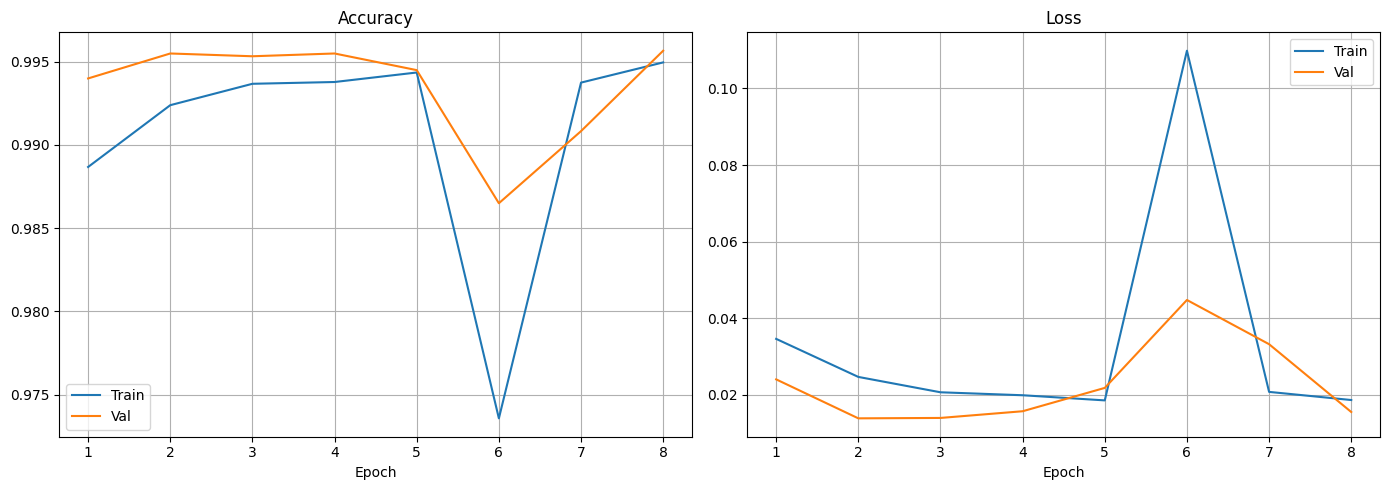

In [24]:
# Cell 9: Combine histories and plot accuracy/loss
hist = {}
for key in history1.history:
    hist[key] = history1.history[key] + history2.history.get(key, [])
epochs = range(1, len(hist['accuracy'])+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs, hist['accuracy'], label='Train')
ax1.plot(epochs, hist['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid()

ax2.plot(epochs, hist['loss'], label='Train')
ax2.plot(epochs, hist['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'artifacts', 'plots', 'training_curves.png'), dpi=150)
plt.show()

Test Loss: 0.0110, Test Accuracy: 0.9965
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step
Optimal threshold (max F1 on validation): 0.100

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      3000
    Positive       1.00      1.00      1.00      3000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



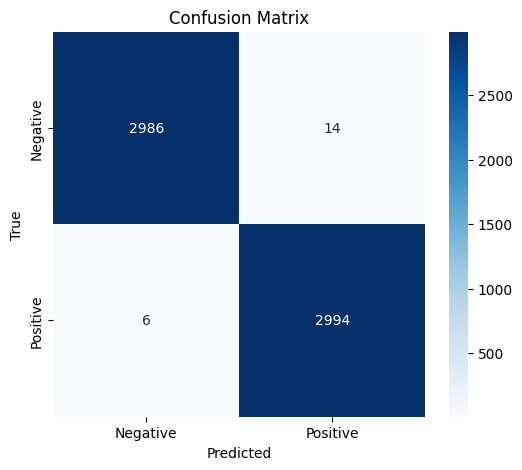

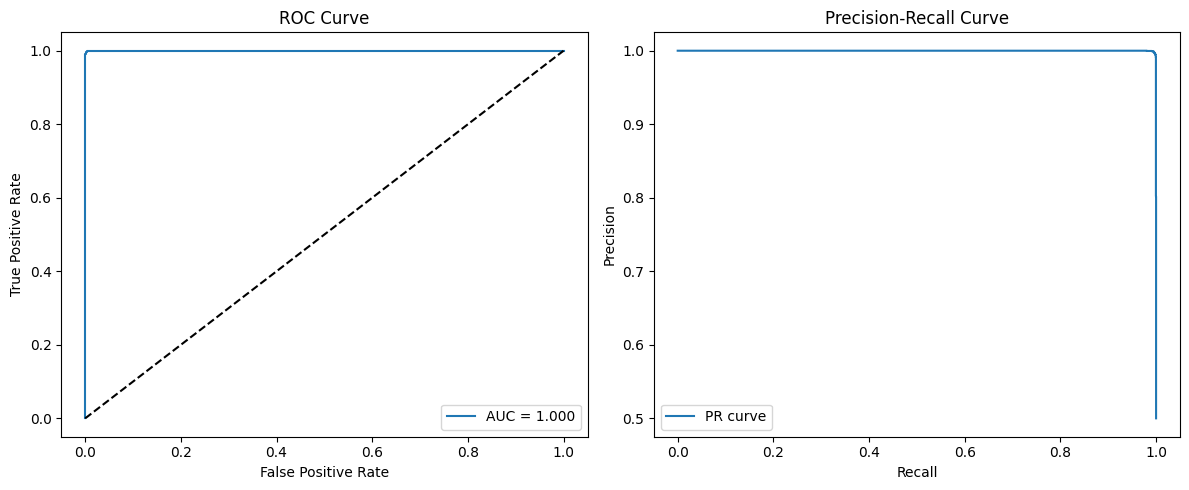

In [25]:
# Cell 10: Evaluate final model on test set and generate metrics
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1).flatten()
y_true = test_gen.classes

# Determine optimal threshold on validation set (to maximise F1)
val_gen.reset()
val_probs = model.predict(val_gen, verbose=0).flatten()
val_true = val_gen.classes
from sklearn.metrics import f1_score
thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = [f1_score(val_true, (val_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1 on validation): {best_threshold:.3f}")

y_pred = (y_pred_probs >= best_threshold).astype(int)

# Metrics
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig(os.path.join(PROJECT_ROOT, 'artifacts', 'plots', 'confusion_matrix.png'), dpi=150)
plt.show()

# ROC & PR curves
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_true, y_pred_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax1.plot([0,1],[0,1],'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

ax2.plot(rec, prec, label=f'PR curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision‑Recall Curve')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'artifacts', 'plots', 'roc_pr_curves.png'), dpi=150)
plt.show()

# Save metrics
metrics = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_acc),
    'best_threshold': float(best_threshold),
    'confusion_matrix': cm.tolist(),
    'roc_auc': float(roc_auc)
}
with open(os.path.join(PROJECT_ROOT, 'artifacts', 'metrics', 'test_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

In [26]:
# Cell 11: Save model in .keras format and create inference config
model.save(os.path.join(PROJECT_ROOT, 'models', 'crack_detector.keras'))
# Also save as SavedModel for serving
model.export(os.path.join(PROJECT_ROOT, 'models', 'saved_model'))

config = {
    'model_path': os.path.join(PROJECT_ROOT, 'models', 'crack_detector.keras'),
    'input_size': IMG_SIZE,
    'threshold': float(best_threshold),
    'class_names': ['Negative', 'Positive'],
    'preprocessing': 'resize to 224x224, rescale 1/255'
}
with open(os.path.join(PROJECT_ROOT, 'models', 'inference_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print("Model and config saved.")

INFO:tensorflow:Assets written to: /kaggle/working/models/saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/models/saved_model/assets


Saved artifact at '/kaggle/working/models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136033344957584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031011259408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031011258640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031051496336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031051495184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031051495376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031011259792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031011260752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031011260368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031011259984: TensorSpec(shape=(), dtype=tf.resource, name=

In [37]:
def grad_cam(image_array, model, layer_name=None, pred_index=0):
    """
    Generate Grad-CAM heatmap. If gradient flow fails, returns a uniform heatmap.
    """
    # Ensure the model is built (call on a dummy input if needed)
    try:
        model(np.zeros((1, 224, 224, 3)))
    except:
        pass

    # The base MobileNetV2
    base_model = model.layers[0]

    # Choose the conv layer output
    if layer_name is None:
        conv_output_tensor = base_model.output
    else:
        conv_output_tensor = base_model.get_layer(layer_name).output

    # Build a model that outputs the conv features
    conv_model = keras.models.Model(inputs=base_model.input, outputs=conv_output_tensor)

    input_tensor = np.expand_dims(image_array, axis=0)

    try:
        with tf.GradientTape() as tape:
            # Forward pass through conv model
            conv_output = conv_model(input_tensor)
            # Forward pass through full model to get prediction
            predictions = model(input_tensor)
            loss = predictions[:, pred_index]

        grads = tape.gradient(loss, conv_output)
        if grads is None:
            raise ValueError("Gradients are None")

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_output = conv_output[0]
        heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_output), axis=-1)
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap) + 1e-8
        return heatmap.numpy()

    except Exception as e:
        print(f"Grad-CAM failed: {e}. Using uniform heatmap.")
        # Return a uniform heatmap (size 7x7, typical for MobileNetV2)
        return np.ones((7, 7))

Testing on sample: 14426.jpg  (true label: Negative)
Grad-CAM failed: Gradients are None. Using uniform heatmap.


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/artifacts/predictions/sample_prediction.png'

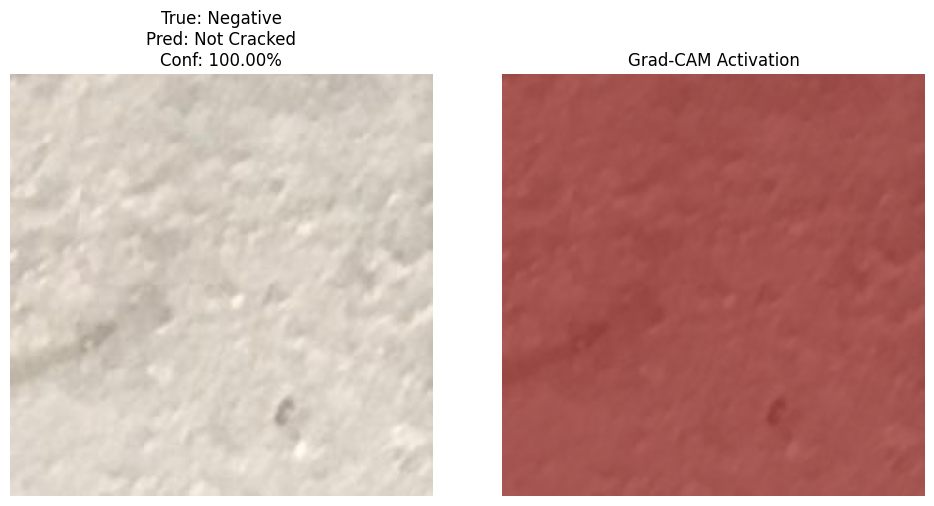

In [42]:
# Cell 13: Predict on a sample image (works on Kaggle)
import os, random
import matplotlib.pyplot as plt

is_kaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None

if is_kaggle:
    # On Kaggle: pick a random image from the test split
    test_positive = os.path.join(split_root, 'test', 'Positive')
    test_negative = os.path.join(split_root, 'test', 'Negative')
    candidates = []
    for f in os.listdir(test_positive):
        candidates.append((os.path.join(test_positive, f), 'Positive'))
    for f in os.listdir(test_negative):
        candidates.append((os.path.join(test_negative, f), 'Negative'))
    if candidates:
        img_path, true_label = random.choice(candidates)
        print(f"Testing on sample: {os.path.basename(img_path)}  (true label: {true_label})")
        label, conf, prob, arr, pil_img = predict_image(img_path)
        heatmap = grad_cam(arr, model)   # now works
        overlay = overlay_heatmap(heatmap, pil_img)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
        ax1.imshow(pil_img)
        ax1.set_title(f"True: {true_label}\nPred: {label}\nConf: {conf:.2%}")
        ax1.axis('off')
        ax2.imshow(overlay)
        ax2.set_title("Grad‑CAM Activation")
        ax2.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(PROJECT_ROOT, 'artifacts', 'predictions', 'sample_prediction.png'), dpi=150)
        plt.show()
        print(f"Result: {label} (confidence {conf:.2%})")
    else:
        print("No test images found.")
else:
    # Colab: use file upload
    from google.colab import files
    print("Upload an image file (JPG/PNG) from your local machine:")
    uploaded = files.upload()
    for fname in uploaded.keys():
        label, conf, prob, arr, pil_img = predict_image(fname)
        heatmap = grad_cam(arr, model)
        overlay = overlay_heatmap(heatmap, pil_img)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
        ax1.imshow(pil_img)
        ax1.set_title(f"Prediction: {label}\nConfidence: {conf:.2%}")
        ax1.axis('off')
        ax2.imshow(overlay)
        ax2.set_title("Grad‑CAM Activation")
        ax2.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(PROJECT_ROOT, 'artifacts', 'predictions', f'pred_{fname}.png'), dpi=150)
        plt.show()
        print(f"Result: {label} (confidence {conf:.2%})")

In [44]:
# Cell: Zip all artifacts for easy download
import zipfile
import os

def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)

# Create a zip of your project folder
project_folder = '/kaggle/working/'
zip_path = '/kaggle/working/artifacts.zip'

if os.path.exists(project_folder):
    zip_folder(project_folder, zip_path)
    print(f"✅ All artifacts zipped to: {zip_path}")
    print("📥 Click on 'Output' in the right panel, then click the file 'artifacts.zip' to download.")
else:
    print("Project folder not found. Make sure you have run the training cells.")

✅ All artifacts zipped to: /kaggle/working/artifacts.zip
📥 Click on 'Output' in the right panel, then click the file 'artifacts.zip' to download.


In [48]:
# Cell: Create ZIP and generate download link
import zipfile
import os
import IPython.display as display

def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)

project_folder = '/kaggle/working/'
zip_path = '/kaggle/working/concrete_data/artifacts.zip'

if os.path.exists(project_folder):
    zip_folder(project_folder, zip_path)
    print("✅ Zip file created at:", zip_path)

    # Generate a download link using a simple HTML anchor
    from IPython.display import HTML
    display.display(HTML(f'<a href="{zip_path}" download="artifacts.zip">Click here to download artifacts.zip</a>'))
    print("📥 If the link doesn't work, go to the Output panel and download the file manually.")
else:
    print("Project folder not found. Make sure training cells have run.")

OSError: [Errno 28] No space left on device